# HW Retinopathy classificationV3

In [20]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from glob import glob
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import pandas as pd

In [21]:
# Define Parameters
NUM_CLASS = 5
IMG_SIZE = 224
BS = 64
DATA_DIR = "/Users/adamw/github-tutorials/llm_tutorial/data/kaggle_retina"
# 用 os 確認資料夾存在，避免後面讀檔才報錯
assert os.path.isdir(DATA_DIR), f"找不到資料夾：{os.path.abspath(DATA_DIR)}"
device = 'cuda' if torch.cuda.is_available() else 'mps'
device

'mps'

#### Data Visualization

In [22]:
df = pd.read_csv(DATA_DIR + "/train.csv")
df.head()

,id_code,diagnosis
0,c1e6fa1ad314,1
1,ed246ae1ed08,4
2,4d3de40ced3a,0
3,ae8472f8d310,1
4,3c28fd846b43,0


In [23]:
paths = glob('/Users/adamw/github-tutorials/llm_tutorial/data/kaggle_retina/train/*.png')
paths_test = sorted(glob('/Users/adamw/github-tutorials/llm_tutorial/data/kaggle_retina/test/*.png'))
len(paths), len(paths_test)

(2197, 1465)

/Users/adamw/github-tutorials/llm_tutorial/data/kaggle_retina/train/4158c340fa49.png
label: 0


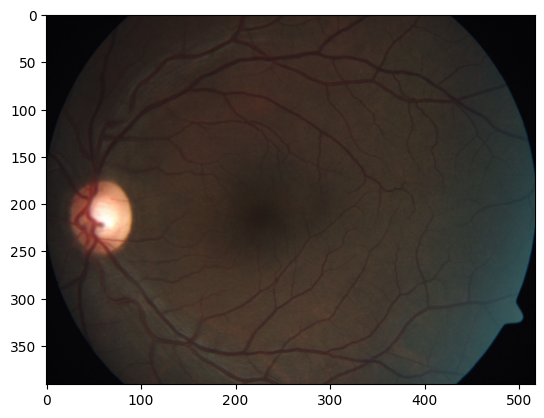

In [24]:
idx = np.random.randint(0, len(df))
row = df.iloc[idx]
filename = row["id_code"]
path = f"{DATA_DIR}/train/{filename}.png"
img = cv2.imread(path)[:, :, ::-1]
plt.imshow(img)
print(path)
print(f'label: {row["diagnosis"]}')

In [25]:
all_cls = df['diagnosis'].tolist()
print(all_cls[:3])

[1, 4, 0]


<BarContainer object of 5 artists>

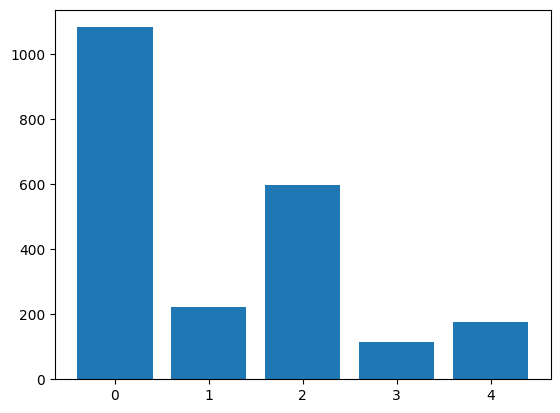

In [26]:
# Class distribution
cls, count = np.unique(all_cls, return_counts=True)
plt.bar(cls, count)

#### Dataset, DataLoader

In [27]:
class RetinaDataset(torch.utils.data.Dataset):
    def __init__(self, df, aug, img_size=224):
        self.df = df
        self.aug = aug
        self.img_size = img_size
        if aug:
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomAffine(45, shear=15, scale=(0.8, 1.2)),
                T.ToTensor(),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.ToTensor(),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"{DATA_DIR}/train/{filename}.png"
        img = Image.open(path).convert('RGB')
        img = self.transform(img)

        label = row["diagnosis"]
        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [28]:
df = pd.read_csv(DATA_DIR + "/train.csv")
train_df, val_df = train_test_split(df,
                                    test_size=0.2, # 8:2
                                    random_state=5566)

In [29]:
train_ds = RetinaDataset(train_df, aug=True, img_size=IMG_SIZE)
val_ds = RetinaDataset(val_df, aug=False, img_size=IMG_SIZE)

1198 tensor(3)


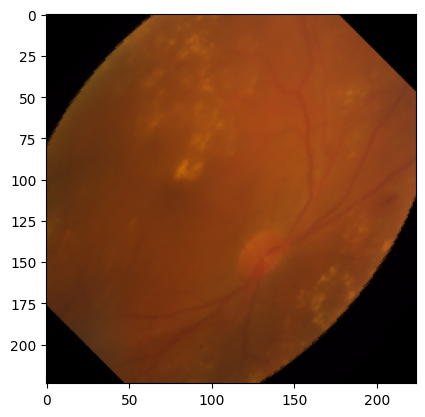

In [30]:
idx = np.random.randint(0, len(train_ds))
img, label = train_ds[idx]
print(idx, label)
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [31]:
train_loader = torch.utils.data.DataLoader(train_ds, BS, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, BS)

#### Model

In [32]:
class RetinaCNN(nn.Module):
    def __init__(self, kernel_size = 3):
        super().__init__()
        # encoder: image to feature map
        self.encoder = nn.Sequential(
            # 用paddding = 'same' 會讓feature map大小跟數入大小一樣
            nn.Conv2d(in_channels=3, out_channels=72, kernel_size=kernel_size, padding='same'),  
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  #image size / 2
            
            nn.Conv2d(72, 128, kernel_size, padding='same'),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size, padding='same'), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   #image size / 4

            nn.Conv2d(256, 128, kernel_size, padding='same'),
            nn.ReLU(),
            nn.Conv2d(128, 64, kernel_size, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   #image size / 8
        )
        # output from encoder 是 (64, 224/8, 224/8)
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 128),
            nn.ReLU(),
            nn.Linear(128, NUM_CLASS)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x
            

In [33]:
model = RetinaCNN(kernel_size=3).to(device)

In [34]:
from torchinfo import summary
summary(model, input_size=(BS, 3, IMG_SIZE, IMG_SIZE), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
RetinaCNN                                [64, 5]                   --
├─Sequential: 1-1                        [64, 64, 28, 28]          --
│    └─Conv2d: 2-1                       [64, 72, 224, 224]        2,016
│    └─ReLU: 2-2                         [64, 72, 224, 224]        --
│    └─MaxPool2d: 2-3                    [64, 72, 112, 112]        --
│    └─Conv2d: 2-4                       [64, 128, 112, 112]       83,072
│    └─ReLU: 2-5                         [64, 128, 112, 112]       --
│    └─Conv2d: 2-6                       [64, 256, 112, 112]       295,168
│    └─ReLU: 2-7                         [64, 256, 112, 112]       --
│    └─MaxPool2d: 2-8                    [64, 256, 56, 56]         --
│    └─Conv2d: 2-9                       [64, 128, 56, 56]         295,040
│    └─ReLU: 2-10                        [64, 128, 56, 56]         --
│    └─Conv2d: 2-11                      [64, 64, 56, 56]          7

In [35]:
# 測試模型輸出
outputs = model(torch.randn(1, 3, 224, 224).to(device))
outputs.shape

torch.Size([1, 5])

#### Training

In [36]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [37]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset) # number of samples
    num_batches = len(dataloader) # batches per epoch

    model.train() # to training mode.
    epoch_loss, epoch_correct = 0, 0
    for batch_i, (x, y) in enumerate(tqdm(dataloader, leave=False)):
        x, y = x.to(device), y.to(device) # move data to GPU

        # zero the parameter gradients
        optimizer.zero_grad()

        # Compute prediction loss
        pred = model(x)
        loss = loss_fn(pred, y)

        # Optimization by gradients
        loss.backward() # backpropagation to compute gradients
        optimizer.step() # update model params

        # write to logs
        epoch_loss += loss.item() # tensor -> python value
        # (N, Class)
        epoch_correct += (pred.argmax(dim=1) == y).sum().item()

    # return avg loss of epoch, acc of epoch
    return epoch_loss/num_batches, epoch_correct/size


def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset) # number of samples
    num_batches = len(dataloader) # batches per epoch

    model.eval() # model to test mode.
    epoch_loss, epoch_correct = 0, 0

    # No gradient for test data
    with torch.no_grad():
        for batch_i, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            # Compute prediction loss
            pred = model(x)
            loss = loss_fn(pred, y)

            # write to logs
            epoch_loss += loss.item()
            epoch_correct += (pred.argmax(1) == y).sum().item()

    return epoch_loss/num_batches, epoch_correct/size

In [38]:
EPOCHS = 100
logs = {
    'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []
}
# Earlystopping
patience = 5
counter = 0
best_loss = np.inf

for epoch in tqdm(range(EPOCHS)):
    train_loss, train_acc = train(train_loader, model, loss_fn, optimizer)
    val_loss, val_acc = test(val_loader, model, loss_fn)

    print(f'EPOCH: {epoch:04d} \
    train_loss: {train_loss:.4f}, train_acc: {train_acc:.3f} \
    val_loss: {val_loss:.4f}, val_acc: {val_acc:.3f} ')

    logs['train_loss'].append(train_loss)
    logs['train_acc'].append(train_acc)
    logs['val_loss'].append(val_loss)
    logs['val_acc'].append(val_acc)

    torch.save(model.state_dict(), "last.pth")
    # chcek improvement
    if val_loss < best_loss:
        counter = 0
        best_loss = val_loss
        torch.save(model.state_dict(), "best.pth")
    else:
        counter += 1
        print(f"Earlystop counter: {counter}/{patience}")
    if counter >= patience:
        print(f"Earlystop at epoch {epoch}")
        break

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0000     train_loss: 1.4072, train_acc: 0.485     val_loss: 1.2734, val_acc: 0.523 


  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0001     train_loss: 1.2954, train_acc: 0.485     val_loss: 1.2603, val_acc: 0.523 


...

EPOCH: 0019     train_loss: 0.8226, train_acc: 0.698     val_loss: 0.8372, val_acc: 0.702 


  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0020     train_loss: 0.8332, train_acc: 0.702     val_loss: 0.8145, val_acc: 0.700 


  0%|          | 0/28 [00:00<?, ?it/s]

EPOCH: 0021     train_loss: 0.7935, train_acc: 0.710     val_loss: 0.9276, val_acc: 0.639 
Earlystop!


#### Kaggle Submission

https://www.kaggle.com/competitions/diabetic-retinopathy-classification-3/overview

In [39]:
model.load_state_dict(torch.load('best.pth'))
_ = model.eval().to(device)

In [43]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_size=224):
        self.df = df
        self.img_size = img_size
        self.transform = T.Compose([
            T.Resize((self.img_size, self.img_size)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"{DATA_DIR}/test/{filename}.png"
        img = Image.open(path).convert('RGB')
        img = self.transform(img)

        return img

df = pd.read_csv('/Users/adamw/github-tutorials/llm_tutorial/data/kaggle_retina/submission.csv')
test_ds = TestDataset(df, IMG_SIZE)
test_loader = torch.utils.data.DataLoader(test_ds, BS)

In [44]:
# Inference
y_pred = []
with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        pred = model(x)
        y_pred.append(pred.argmax(dim=1))

y_pred = torch.cat(y_pred, dim=0).cpu().numpy()

In [45]:
df['diagnosis'] = y_pred
df.to_csv('submission.csv', index=None)

ACC: 0.63822

#### Using torchvision.transforms

In [ ]:
from PIL import Image
import torchvision.transforms as T

class RetinaDataset(torch.utils.data.Dataset):
    def __init__(self, df, aug, img_size=224):
        self.df = df
        self.aug = aug
        self.img_size = img_size
        if aug:
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomAffine(45, shear=15, scale=(0.8, 1.2))
                T.ToTensor(),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((self.img_size, self.img_size)),
                T.ToTensor(),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"kaggle_retina/train/{filename}.png"
        img = Image.open(path).convert('RGB')
        img = self.transform(img)

        label = row["diagnosis"]
        label = torch.tensor(label, dtype=torch.long)

        return img, label

# For testing
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_size=224):
        self.df = df
        self.img_size = img_size
        self.transform = T.Compose([
            T.Resize((self.img_size, self.img_size)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"kaggle_retina/train/{filename}.png"
        img = Image.open(path).convert('RGB')
        img = self.transform(img)

        return img

imgaug 寫法

In [ ]:
# 安裝 imgaug
!pip install numpy==1.26.3
!pip install imgaug

import imgaug.augmenters as iaa
import imgaug as ia

class RetinaDataset(torch.utils.data.Dataset):
    """ OpenCV """
    def __init__(self, df, aug, img_size=224):
        self.df = df
        self.transform = iaa.Sequential([
            iaa.Fliplr(0.5), # 50% horizontal flip
            iaa.Flipud(0.5), # 50% vertical flip
            iaa.Affine(
                rotate=(-45, 45),
                shear=(-16, 16),
                scale={"x": (0.8, 1.2), "y": (0.8, 1.2)}
            ),
        ])
        self.aug = aug
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"kaggle_retina/train/{filename}.png"
        img = cv2.imread(path)[:, :, ::-1]
        img = cv2.resize(img, (self.img_size, self.img_size))
        if self.aug:
            img = self.transform.augment_image(image=img)
        img = img / 255.
        label = row["diagnosis"]

        img = torch.tensor(img, dtype=torch.float).permute(2, 0, 1) # (C, H, W)
        label = torch.tensor(label, dtype=torch.long)

        return img, label

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_size=224):
        self.df = df
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row["id_code"]
        path = f"kaggle_retina/test/{filename}.png"
        img = cv2.imread(path)[:,:,::-1]
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img / 255.
        img = torch.tensor(img, dtype=torch.float).permute(2, 0, 1)
        return img